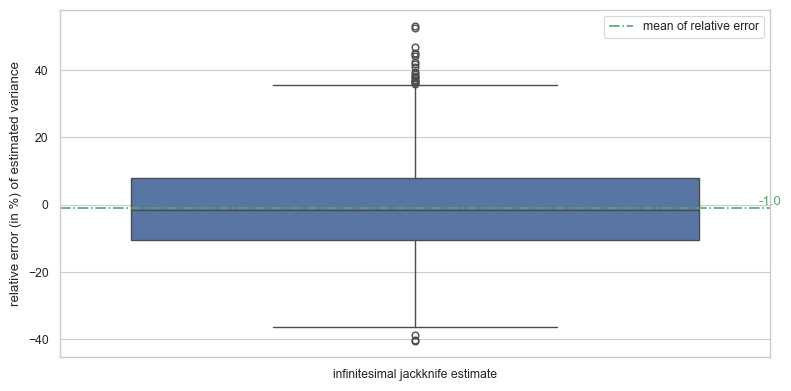

In [9]:
###### MEAN()

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
sim_n = 2000  # number of simulations
n = 100       # sample size
true_variance = 1 / n  # true variance

# Initialize array to store jackknife variances
se_jackknife_sim = np.zeros(sim_n)

# Set random seed for reproducibility
np.random.seed(42)

# Run simulations
for i in range(sim_n):
    x = np.random.normal(0, 1, n)
    # Jackknife estimate of the variance
    se_jackknife_sim[i] = (np.var(x, ddof=1) / n) * ((n-1)/n)

# Calculate relative error
relative_error = (se_jackknife_sim - true_variance) / true_variance *100

# Convert the results to a DataFrame for easier handling with Seaborn
df = pd.DataFrame({'infinitesimal jackknife estimate': relative_error})

# Plot with Seaborn
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper', style="whitegrid")  # Setting the style to whitegrid
sns.boxplot(data=df)

plt.text(0.5, np.mean(relative_error), f'{np.mean(relative_error):.1f}', color='g', ha='center', va='bottom')

plt.axhline(y=df[df.columns[0]].mean(), color='g', linestyle='dashdot', label='mean of relative error')  # Add a line for the mean relative error
plt.ylabel('relative error (in %) of estimated variance')
plt.legend()
plt.tight_layout()
plt.savefig("boxplot_relative_error_inf_jack_mean.png", dpi=1000)  # dpi anpassen für bessere Qualität

plt.show()

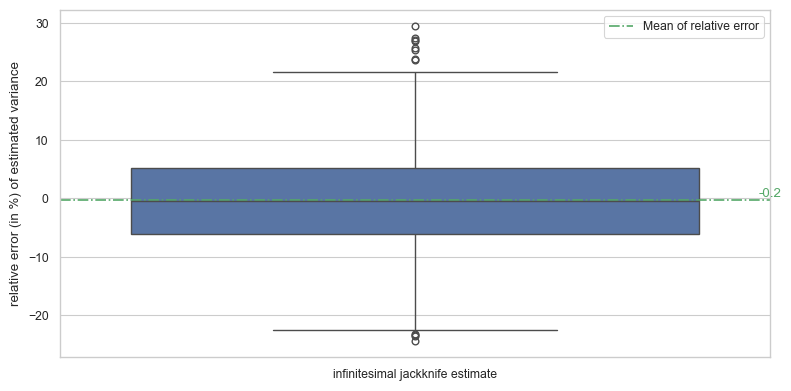

In [12]:
#### Pearson correlation coefficient ###
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def mean_weighted(x,p_i):
    return np.sum(x*p_i)

def inf_jack_corr(x,y,func,e):
    n = len(x)
    T_0 = func(x,y)[0,1]
    U_i = np.zeros(len(x))
    for i in range(n):
        weights_inf_jk  = np.full(n, (1 - e) / n)
        weights_inf_jk[i] += e
        mean_x = mean_weighted(x,weights_inf_jk)
        mean_y = mean_weighted(y,weights_inf_jk)
        T_weighted = np.sum(weights_inf_jk*(x-mean_x)*(y-mean_y)) /   np.sqrt( np.sum(weights_inf_jk*(x-mean_x)**2) * np.sum(weights_inf_jk*(y-mean_y)**2) )
        U_i[i] = (T_weighted - T_0 )/e
    return  np.sqrt(np.sum(U_i**2)/n**2)

### Simulation ###

# ZV´s
mean = [0, 0]          
p = 0.7     
cov = [[1,p], [p, 1]] 

sim_n = 2_000 
n = 400        

se_jackknife_inf = np.zeros(sim_n)

np.random.seed(42)
for i in range(sim_n):
    x, y = np.random.multivariate_normal(mean, cov, n).T
    se_jackknife_inf[i] = inf_jack_corr(x,y, np.corrcoef,0.000000001)
    
# true std for the correlation https://www.jstor.org/stable/pdf/2277400.pdf?refreqid=fastly-default%3Aef46e66363b4ca95a1a81b2e1b6d92f0&ab_segments=&origin=&initiator=&acceptTC=1
true_variance = (1-p**2)/np.sqrt(n)
relative_error = (se_jackknife_inf - true_variance) / true_variance *100
df = pd.DataFrame({'infinitesimal jackknife estimate': relative_error})

# Plot with Seaborn
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper', style="whitegrid")  
sns.boxplot(data=df)
plt.axhline(y=df[df.columns[0]].mean(), color='g', linestyle='dashdot', label='mean of relative error')  # Add a line for the mean relative error
plt.ylabel('relative error (in %) of estimated variance')
plt.text(0.5, np.mean(relative_error), f'{np.mean(relative_error):.1f}', color='g', ha='center', va='bottom')
plt.legend()
plt.tight_layout()
plt.savefig("boxplot_relative_error_inf_jack_corr.png", dpi=1000)  
plt.show()


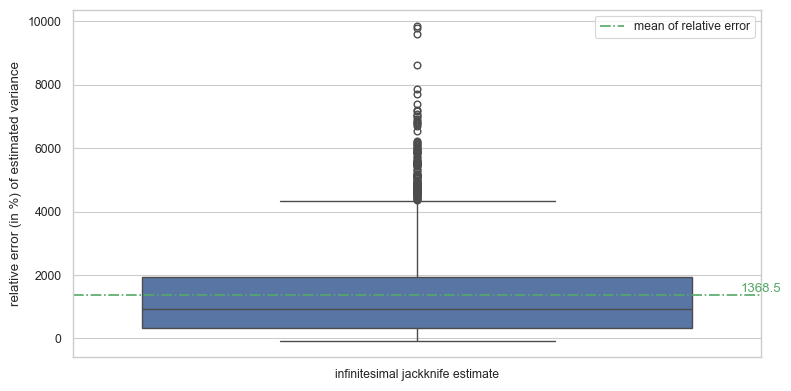

In [17]:
#### Median estimation ###
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def weighted_quantile(values, quantiles, sample_weight=None, 
                      values_sorted=False, old_style=False):
    """ Very close to numpy.percentile, but supports weights.
    NOTE: quantiles should be in [0, 1]!
    :param values: numpy.array with data
    :param quantiles: array-like with many quantiles needed
    :param sample_weight: array-like of the same length as `array`
    :param values_sorted: bool, if True, then will avoid sorting of
        initial array
    :param old_style: if True, will correct output to be consistent
        with numpy.percentile.
    :return: numpy.array with computed quantiles.
    """
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.array(sample_weight)
    assert np.all(quantiles >= 0) and np.all(quantiles <= 1), \
        'quantiles should be in [0, 1]'

    if not values_sorted:
        sorter = np.argsort(values)
        values = values[sorter]
        sample_weight = sample_weight[sorter]

    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    if old_style:
        # To be convenient with numpy.percentile
        weighted_quantiles -= weighted_quantiles[0]
        weighted_quantiles /= weighted_quantiles[-1]
    else:
        weighted_quantiles /= np.sum(sample_weight)
    return np.interp(quantiles, weighted_quantiles, values)

def inf_jack_median(x, func, e):
    n = len(x)
    T_0 = func(x)
    U_i = np.zeros(n)
    for i in range(n):
        weights_inf_jk = np.full(n, (1 - e) / n)
        weights_inf_jk[i] += e
        T_weighted = weighted_quantile(x, 0.5, sample_weight=weights_inf_jk*200)
        U_i[i] = (T_weighted - T_0) / e
    return np.sqrt(np.sum(U_i**2) / n**2)

### Simulation ###
sim_n = 2_000  
n = 400    
se_jackknife_inf = np.zeros(sim_n)
median_sim = np.zeros(sim_n)

np.random.seed(42)
for i in range(sim_n):
    x = np.random.normal(0, 1, n)
    se_jackknife_inf[i] = inf_jack_median(x, np.median, 0.000000001)
    median_sim[i] = np.median(x)


true_variance = np.var(median_sim)
relative_error = (se_jackknife_inf - true_variance) / true_variance
df = pd.DataFrame({'infinitesimal jackknife estimate': relative_error*100})

# Plot with Seaborn
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper', style="whitegrid") 
sns.boxplot(data=df)
plt.axhline(y=df[df.columns[0]].mean(), color='g', linestyle='dashdot', label='mean of relative error') 
plt.ylabel('relative error (in %) of estimated variance')
plt.legend()
plt.text(0.5, np.mean(relative_error*100), f'{np.mean(relative_error*100):.1f}', color='g', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("boxplot_relative_error_inf_jack_median.png", dpi=1000) 
plt.show()
